In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import xarray as xr
from glob import glob
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

In [15]:
df = pd.read_csv(r'Data\DataTrain.csv')
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Lon, df.Lat))

In [16]:
gdfNull = gdf[gdf.isnull().any(axis=1)]

In [17]:
badCoords = gdfNull['geometry'].unique()

In [18]:
ds = xr.open_mfdataset(glob(r'Data\HydroGFD\data_files\prAdjust*.nc'), combine='by_coords')

In [19]:
coastPointDF = badCoords[badCoords.geom_equals_exact(Point(102.28, 6.17), tolerance=0.01)]
antPointDF = badCoords[badCoords.geom_equals_exact(Point(-63.98, -65.08), tolerance=0.01)]
coastPoint = coastPointDF[0]
antPoint = antPointDF[0]

In [20]:
def find_nearest_valid_grid(ds, point, time, buffer=5):
    # Arguments
    # ds: xarray dataset containing the variable of interest (e.g., 'prAdjust')
    # point: shapely Point object with the coordinates of the target location
    # time: the specific time for which to find the nearest valid grid point
    # buffer: the size of the area around the point to consider for finding valid grid points
    # Returns
    # The value of the nearest valid grid point for the specified time
    dsFiltered = ds.sel(
        lon=slice(point.x - buffer, point.x + buffer), 
        lat=slice(point.y - buffer, point.y + buffer),
        time=time)['prAdjust']
    
    mask = np.isnan(dsFiltered.values)
    dist, ids = distance_transform_edt(mask, return_indices=True)
    
    data = dsFiltered.values.copy()
    data[mask] = data[tuple(ids[:, mask])]
    
    filled_arr = xr.DataArray(data, coords=dsFiltered.coords, dims=dsFiltered.dims)
    
    return filled_arr, filled_arr.sel(lon=point.x, lat=point.y, method='nearest').values.item()

In [21]:
arr_filled = find_nearest_valid_grid(ds, coastPoint, '1991-08-14', buffer=5)[0]

In [44]:
def plot_distance_transform(ds, point, buffer=5):
    fig, ax = plt.subplots()
    world = gpd.read_file(geodatasets.get_path('naturalearth_land'))
    worldFiltered = world.cx[point.x - buffer:point.x + buffer, point.y - buffer:point.y + buffer]
    ds.plot(ax=ax, x='lon', y='lat', cmap='viridis')
    worldFiltered.plot(ax=ax, color='none', edgecolor='black')
    ax.plot(point.x, point.y, 'ro', label='Target Point')
    return fig, ax

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'time = 1991-08-14T12:00:00'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

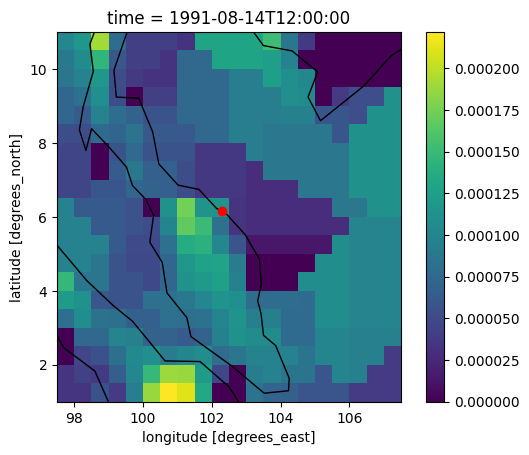

In [45]:
plot_distance_transform(arr_filled, coastPoint, buffer=5)

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'time = 1972-11-14T12:00:00'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

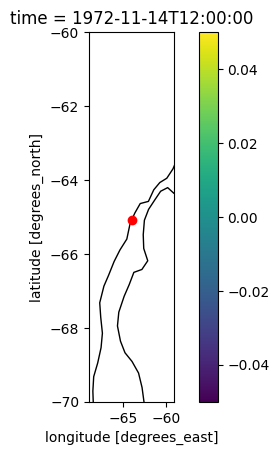

In [24]:
# Now the antarctic point (1972-11-14)
da, val = find_nearest_valid_grid(ds, antPoint, '1972-11-14', buffer=5)
plot_distance_transform(da, antPoint, buffer=5)

ValueError: aspect must be finite and positive 

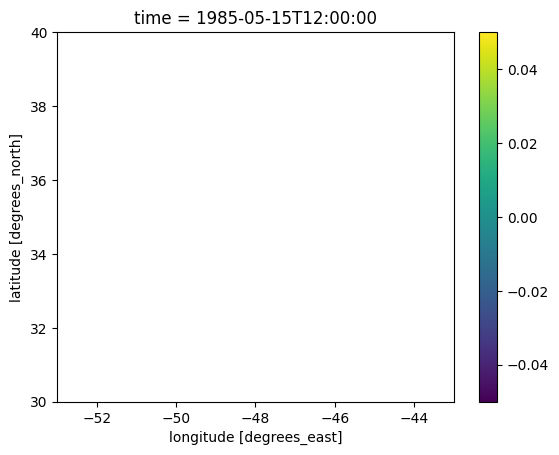

In [25]:
da, val = find_nearest_valid_grid(ds, Point(-48, 35), '1985-05-15', buffer=5)
plot_distance_transform(da, Point(-48, 35), buffer=5)

In [ ]:
# Function to plot a point on a map with a buffer zone
def plot_point_with_buffer(point, buffer=5):
    fig, ax = plt.subplots()
    world = gpd.read_file(geodatasets.get_path('naturalearth_land'))
    worldFiltered = world.cx[point.x - buffer:point.x + buffer, point.y - buffer:point.y + buffer]
    worldFiltered.plot(ax=ax, color='none', edgecolor='black')
    return fig, ax

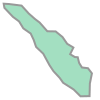

In [77]:
#fig, ax = plt.subplots()
world = gpd.read_file(geodatasets.get_path('naturalearth_land'))
worldFiltered = world.cx[coastPoint.x - 5:coastPoint.x + 5, coastPoint.y - 5:coastPoint.y + 5]
worldFiltered.iloc[0].geometry